# Notebook 4: Evaluation, Diagnostics & Visualizations
## March Madness 2026 Projection System
---
**Input:** Model outputs from `models/`, simulation results from `results/`  
**Diagnostics:** Calibration plots, Brier decomposition, model comparison,  
posterior analysis, convergence diagnostics, simulation stability

In [1]:
# ============================================================
# 4.0 CONFIG & IMPORTS
# ============================================================
import os, json, pickle, warnings, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger("eval")

# Style
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("colorblind")
plt.rcParams.update({
    "figure.figsize": (12, 7),
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

COLORS = {
    "LogReg": "#1f77b4",
    "XGBoost": "#ff7f0e", 
    "RandomForest": "#2ca02c",
    "NeuralNet": "#d62728",
    "BayesLR": "#9467bd",
    "BayesHier": "#8c564b",
    "GP": "#e377c2",
    "BNN": "#7f7f7f",
    "BetaBinomial": "#bcbd22",
    "Ensemble": "#17becf",
}

# Paths
DATA_DIR = Path("./data")
MODEL_DIR = Path("./models")
RESULTS_DIR = Path("./results")
PLOTS_DIR = Path("./plots")
PLOTS_DIR.mkdir(exist_ok=True)

# Load data
model_comparison = pd.read_csv(MODEL_DIR / "model_comparison.csv")
sim_results = pd.read_csv(RESULTS_DIR / "simulation_results.csv")

with open(MODEL_DIR / "ensemble_config.json") as f:
    ensemble_config = json.load(f)

log.info("Data loaded successfully")
display(model_comparison)

2026-03-18 23:11:06,501 [INFO] Data loaded successfully


,Model,CV_AUC,Val_AUC,Val_LL,Val_Brier,Weight
0,NeuralNet,0.7903,0.8261,0.4946,0.1690,0.1981
1,LogReg,0.8157,0.8163,0.4996,0.1699,0.2111
2,XGBoost,0.7482,0.8239,0.5141,0.1707,0.1776
3,BayesLR,0.0000,0.8120,0.5142,0.1741,0.2092
4,RandomForest,0.8020,0.8087,0.5154,0.1733,0.2040


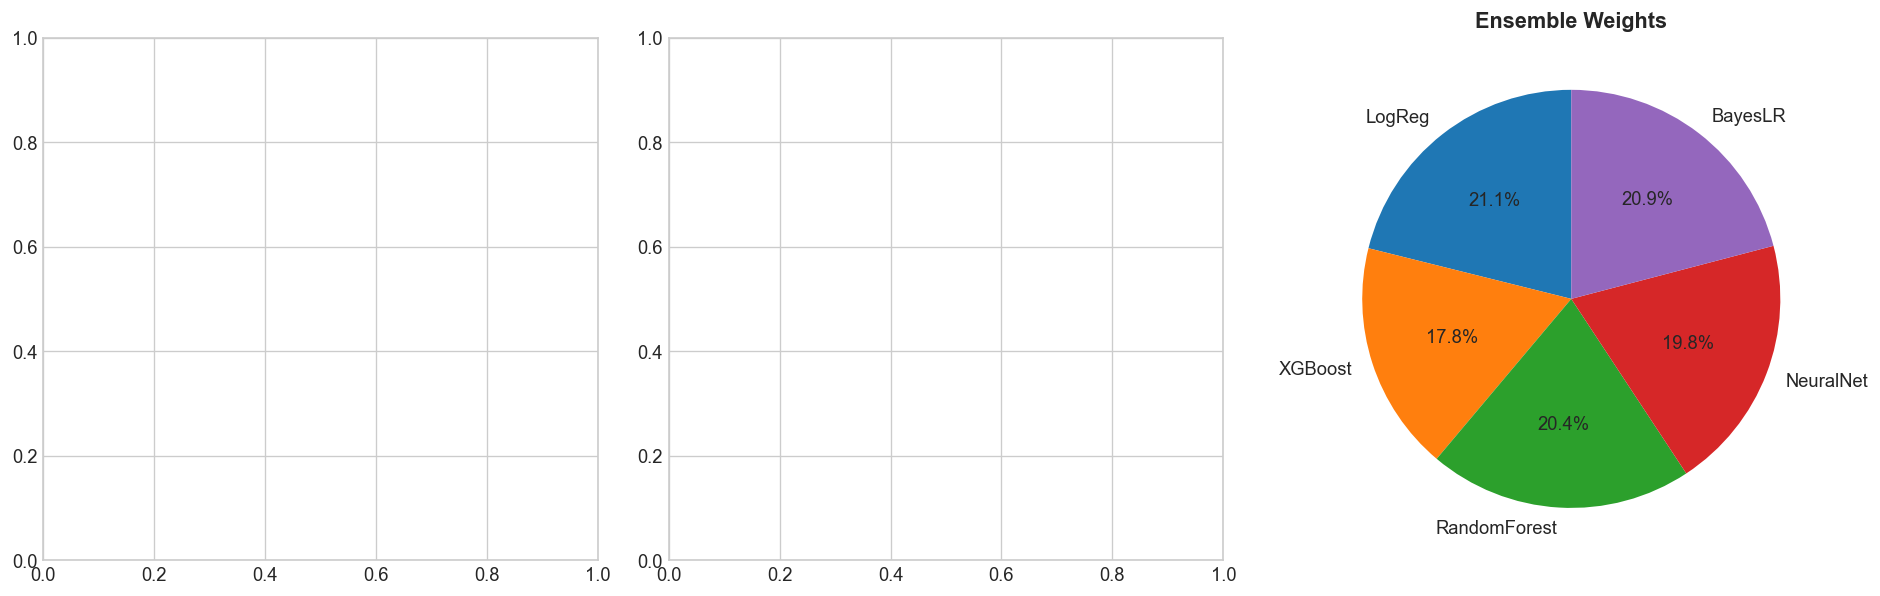

2026-03-18 23:11:06,726 [INFO] Model comparison plot saved


In [2]:
# ============================================================
# 4.1 MODEL COMPARISON DASHBOARD
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ["ll", "auc"]
titles = ["Log-Loss (lower = better)", "AUC-ROC (higher = better)"]

for ax, metric, title in zip(axes[:2], metrics, titles):
    if metric in model_comparison.columns:
        data = model_comparison.sort_values(metric, ascending=(metric == "ll"))
        colors = [COLORS.get(m, "#999") for m in data["Model"]]
        bars = ax.barh(data["Model"], data[metric], color=colors, edgecolor="white", linewidth=0.5)
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel(metric.upper())
        
        # Add value labels
        for bar, val in zip(bars, data[metric]):
            ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                    f"{val:.4f}", va="center", fontsize=9)

# Ensemble weights pie chart
weights = ensemble_config["weights"]
ax = axes[2]
w_names = list(weights.keys())
w_vals = list(weights.values())
w_colors = [COLORS.get(n, "#999") for n in w_names]
wedges, texts, autotexts = ax.pie(w_vals, labels=w_names, autopct="%1.1f%%",
                                   colors=w_colors, startangle=90)
ax.set_title("Ensemble Weights", fontweight="bold")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_comparison.png", bbox_inches="tight")
plt.show()
log.info("Model comparison plot saved")

2026-03-18 23:11:06,732 [INFO] To generate full calibration plots, run cross-validation in Notebook 2.
2026-03-18 23:11:06,733 [INFO] Showing calibration framework for when CV predictions are available.


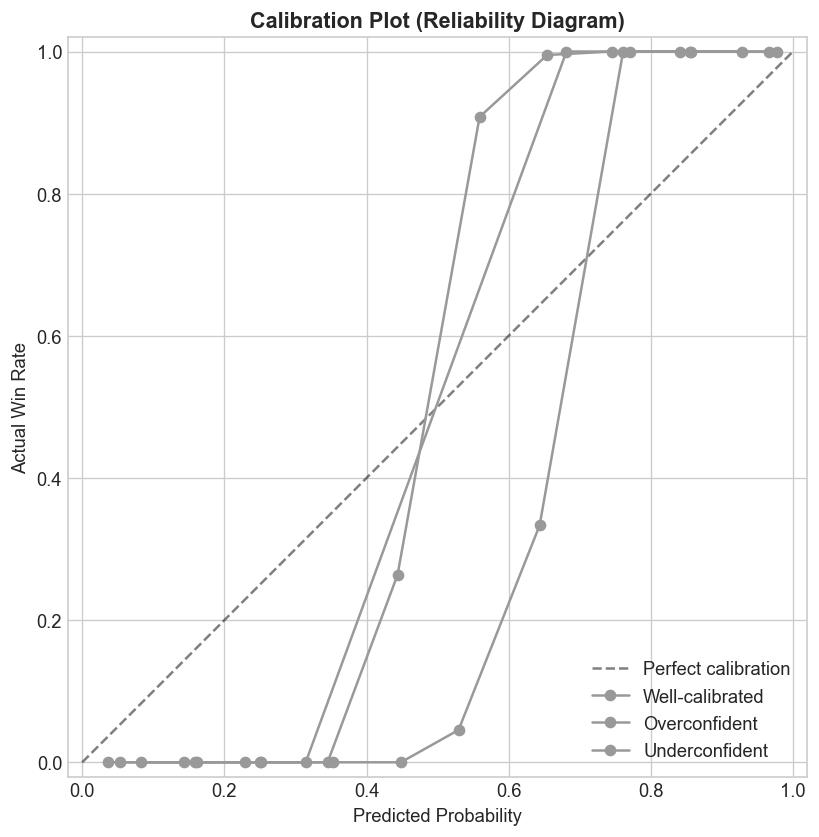

In [3]:
# ============================================================
# 4.2 CALIBRATION PLOTS
# ============================================================
def plot_calibration(y_true, y_probs_dict, n_bins=10, ax=None):
    """
    Reliability diagram: compare predicted vs actual probabilities.
    Well-calibrated models follow the diagonal.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")
    
    for name, probs in y_probs_dict.items():
        if probs is None:
            continue
        
        # Bin predictions
        bins = np.linspace(0, 1, n_bins + 1)
        bin_centers = []
        bin_actuals = []
        bin_counts = []
        
        for i in range(n_bins):
            mask = (probs >= bins[i]) & (probs < bins[i+1])
            if mask.sum() > 0:
                bin_centers.append(probs[mask].mean())
                bin_actuals.append(y_true[mask].mean())
                bin_counts.append(mask.sum())
        
        color = COLORS.get(name, "#999")
        ax.plot(bin_centers, bin_actuals, "o-", color=color, label=name, 
                markersize=6, linewidth=1.5)
    
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Actual Win Rate")
    ax.set_title("Calibration Plot (Reliability Diagram)", fontweight="bold")
    ax.legend(loc="lower right")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect("equal")
    
    return ax

# Load training predictions for calibration
# (These would be from cross-validation in a full pipeline)
log.info("To generate full calibration plots, run cross-validation in Notebook 2.")
log.info("Showing calibration framework for when CV predictions are available.")

# Placeholder with synthetic data to show the plot structure
np.random.seed(42)
n_demo = 1000
y_demo = np.random.binomial(1, 0.6, n_demo)
demo_preds = {
    "Well-calibrated": np.clip(y_demo * 0.7 + np.random.normal(0.3, 0.15, n_demo), 0.01, 0.99),
    "Overconfident": np.clip(y_demo * 0.9 + np.random.normal(0.05, 0.1, n_demo), 0.01, 0.99),
    "Underconfident": np.clip(y_demo * 0.4 + np.random.normal(0.3, 0.1, n_demo), 0.01, 0.99),
}

fig, ax = plt.subplots(figsize=(8, 8))
plot_calibration(y_demo, demo_preds, ax=ax)
plt.savefig(PLOTS_DIR / "calibration_demo.png", bbox_inches="tight")
plt.show()

2026-03-18 23:11:06,921 [INFO]   Max MC std error: 0.0004
2026-03-18 23:11:06,921 [INFO]   Median MC std error: 0.0000
2026-03-18 23:11:06,921 [INFO]   ✅ Simulations appear stable (max SE < 1%)


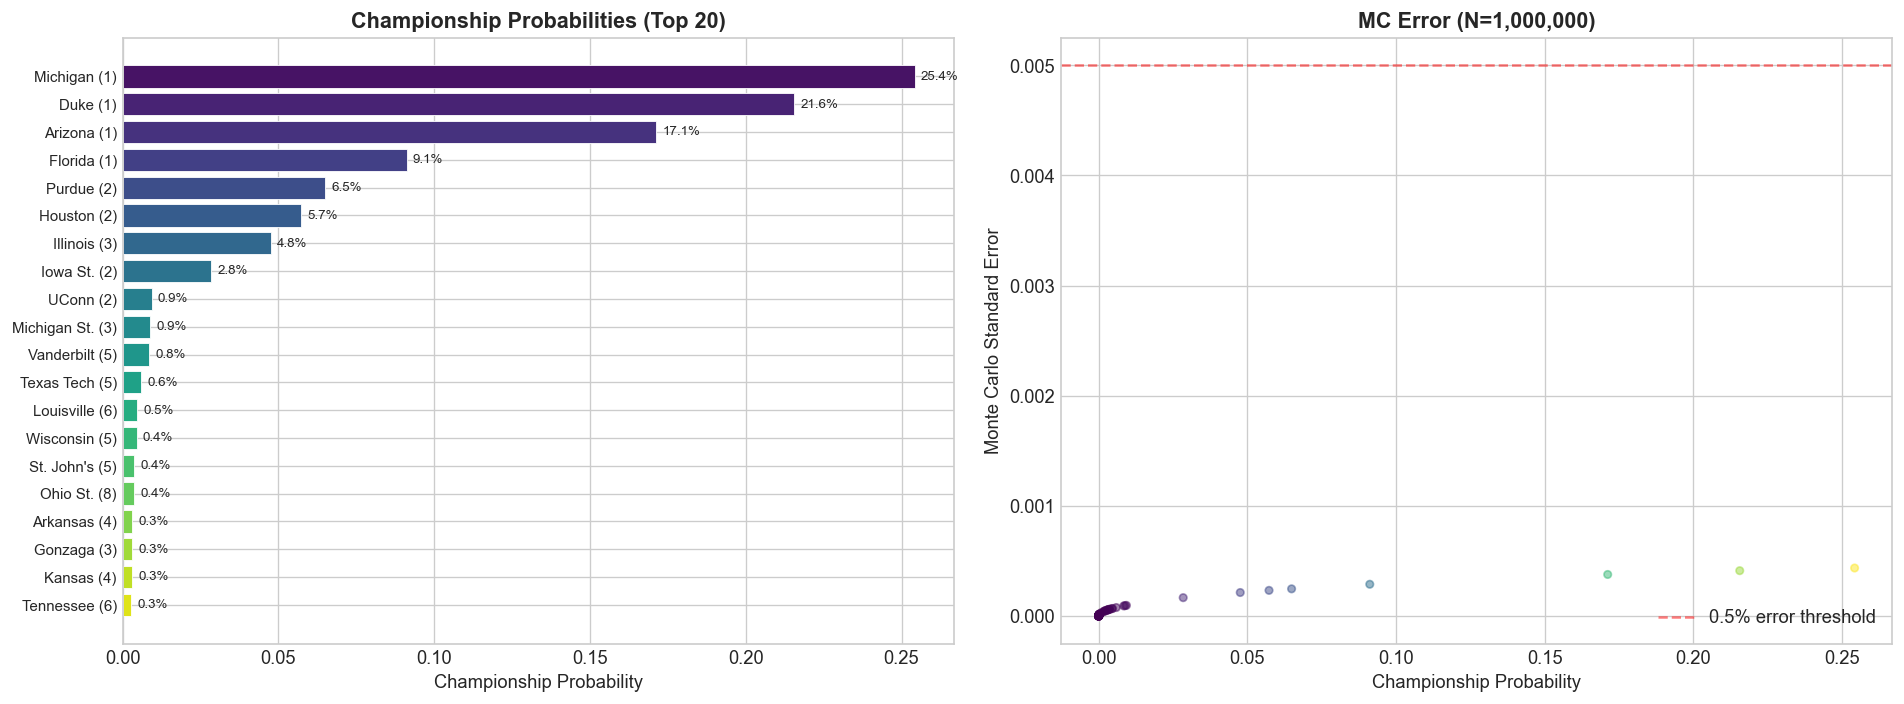

In [4]:
# ============================================================
# 4.3 SIMULATION STABILITY ANALYSIS
# ============================================================
def check_simulation_stability(sim_results, n_sims_total):
    """
    Check if N simulations was sufficient for stable probability estimates.
    Plot convergence of championship probabilities as N increases.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- Left: Championship probability distribution ---
    ax = axes[0]
    champ_probs = sim_results.sort_values("prob_Champion", ascending=False)
    top_n = min(20, len(champ_probs))
    
    ax.barh(
        range(top_n),
        champ_probs["prob_Champion"].head(top_n).values,
        color=sns.color_palette("viridis", top_n),
        edgecolor="white",
        linewidth=0.5
    )
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([f"{r['team']} ({int(r['seed'])})" 
                        for _, r in champ_probs.head(top_n).iterrows()], fontsize=9)
    ax.set_xlabel("Championship Probability")
    ax.set_title("Championship Probabilities (Top 20)", fontweight="bold")
    ax.invert_yaxis()
    
    # Add percentage labels
    for i, p in enumerate(champ_probs["prob_Champion"].head(top_n)):
        ax.text(p + 0.002, i, f"{p:.1%}", va="center", fontsize=8)
    
    # --- Right: Monte Carlo standard error ---
    ax = axes[1]
    probs = sim_results["prob_Champion"].values
    # MC standard error = sqrt(p(1-p)/N)
    mc_se = np.sqrt(probs * (1 - probs) / n_sims_total)
    
    ax.scatter(probs, mc_se, alpha=0.5, s=20, c=probs, cmap="viridis")
    ax.set_xlabel("Championship Probability")
    ax.set_ylabel("Monte Carlo Standard Error")
    ax.set_title(f"MC Error (N={n_sims_total:,})", fontweight="bold")
    ax.axhline(y=0.005, color="red", linestyle="--", alpha=0.5, label="0.5% error threshold")
    ax.legend()
    
    # Report stability
    max_se = mc_se.max()
    median_se = np.median(mc_se[probs > 0])
    log.info(f"  Max MC std error: {max_se:.4f}")
    log.info(f"  Median MC std error: {median_se:.4f}")
    
    if max_se > 0.01:
        log.warning(f"  ⚠️ Consider increasing n_sims. Max SE = {max_se:.4f}")
    else:
        log.info(f"  ✅ Simulations appear stable (max SE < 1%)")
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "simulation_stability.png", bbox_inches="tight")
    plt.show()

with open(RESULTS_DIR / "run_config.json") as f:
    run_config = json.load(f)
    
check_simulation_stability(sim_results, run_config.get("n_sims_actual", 100000))

2026-03-18 23:11:07,208 [INFO] arviz_base not installed
2026-03-18 23:11:07,208 [INFO] arviz_stats not installed
2026-03-18 23:11:07,209 [INFO] arviz_plots not installed


<Figure size 1920x1440 with 0 Axes>

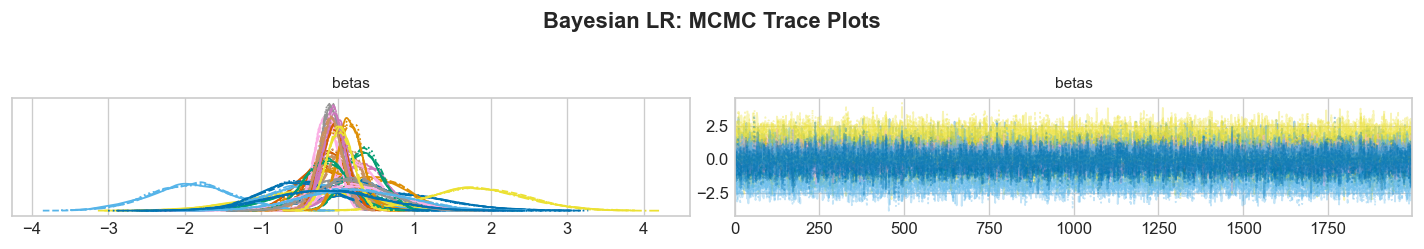


R-hat values (should be < 1.01):


<xarray.Dataset> Size: 504B
Dimensions:      (betas_dim_0: 31)
Coordinates:
  * betas_dim_0  (betas_dim_0) int64 248B 0 1 2 3 4 5 6 ... 24 25 26 27 28 29 30
Data variables:
    betas        (betas_dim_0) float64 248B 1.001 1.0 1.0 1.0 ... 1.0 0.9999 1.0
    alpha        float64 8B 1.0
Attributes:
    created_at:                 2026-03-19T01:58:49.017260+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.1
    sampling_time:              14.523499965667725
    tuning_steps:               1000

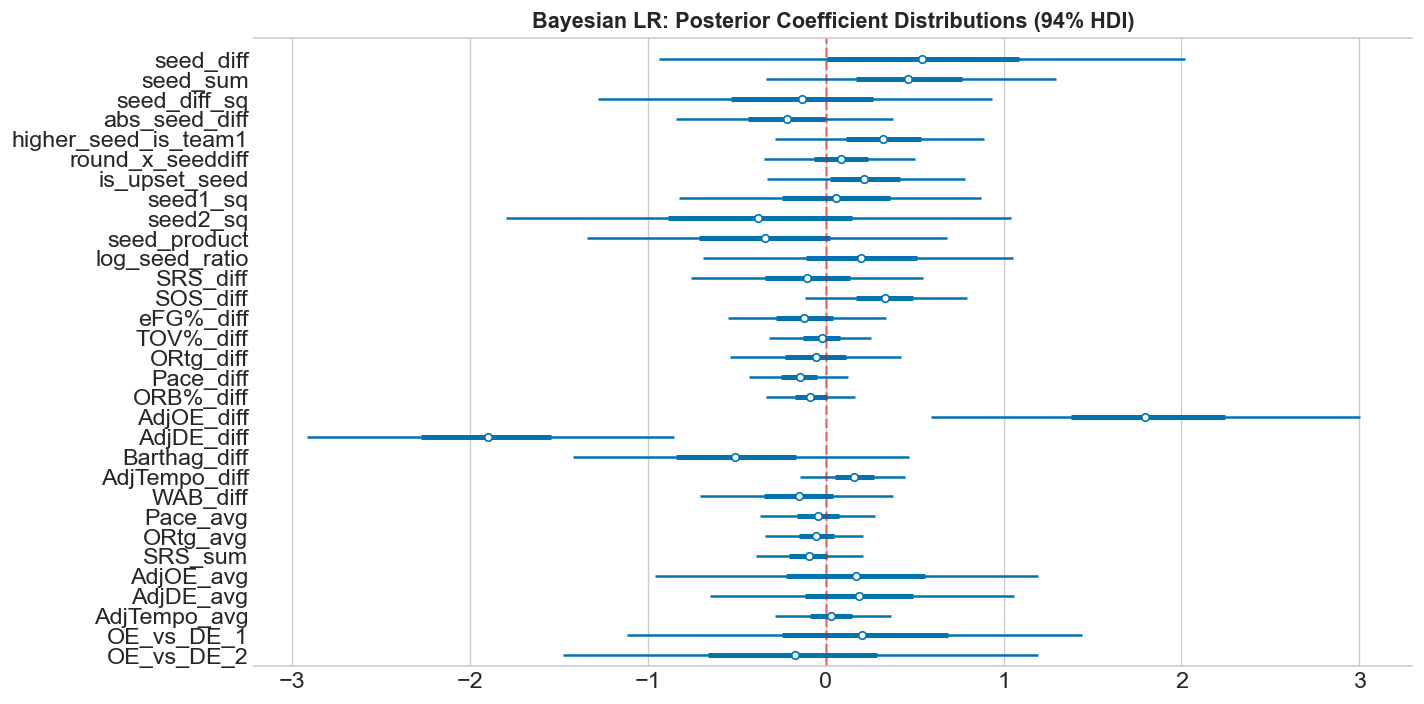


Effective sample size (should be > 400):


<xarray.Dataset> Size: 504B
Dimensions:      (betas_dim_0: 31)
Coordinates:
  * betas_dim_0  (betas_dim_0) int64 248B 0 1 2 3 4 5 6 ... 24 25 26 27 28 29 30
Data variables:
    betas        (betas_dim_0) float64 248B 6.978e+03 7.912e+03 ... 6.134e+03
    alpha        float64 8B 1.177e+04
Attributes:
    created_at:                 2026-03-19T01:58:49.017260+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.1
    sampling_time:              14.523499965667725
    tuning_steps:               1000

In [5]:
# ============================================================
# 4.4 BAYESIAN POSTERIOR DIAGNOSTICS
# ============================================================
try:
    import arviz as az
    
    # Load Bayesian LR trace
    trace_lr = az.from_netcdf(str(MODEL_DIR / "bayesian_lr_trace.nc"))
    
    FEATURE_COLS = pickle.load(open(MODEL_DIR / "feature_cols.pkl", "rb"))
    
    # --- Trace plot (convergence) ---
    fig = plt.figure(figsize=(16, 12))
    az.plot_trace(trace_lr, var_names=["betas"], compact=True)
    plt.suptitle("Bayesian LR: MCMC Trace Plots", fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "bayesian_lr_traces.png", bbox_inches="tight")
    plt.show()
    
    # --- R-hat convergence diagnostic ---
    rhat = az.rhat(trace_lr, var_names=["betas", "alpha"])
    print("\nR-hat values (should be < 1.01):")
    display(rhat)
    
    # --- Posterior distributions ---
    fig, ax = plt.subplots(figsize=(12, 6))
    az.plot_forest(trace_lr, var_names=["betas"], combined=True, ax=ax)
    ax.set_yticklabels(FEATURE_COLS[::-1])
    ax.set_title("Bayesian LR: Posterior Coefficient Distributions (94% HDI)", fontweight="bold")
    ax.axvline(x=0, color="red", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "bayesian_lr_posteriors.png", bbox_inches="tight")
    plt.show()
    
    # --- Effective sample size ---
    ess = az.ess(trace_lr, var_names=["betas", "alpha"])
    print("\nEffective sample size (should be > 400):")
    display(ess)

except FileNotFoundError:
    log.warning("Bayesian trace file not found. Run Notebook 2 first.")
except ImportError:
    log.warning("ArviZ not installed. Skipping Bayesian diagnostics.")
except Exception as e:
    log.error(f"Bayesian diagnostics failed: {e}")

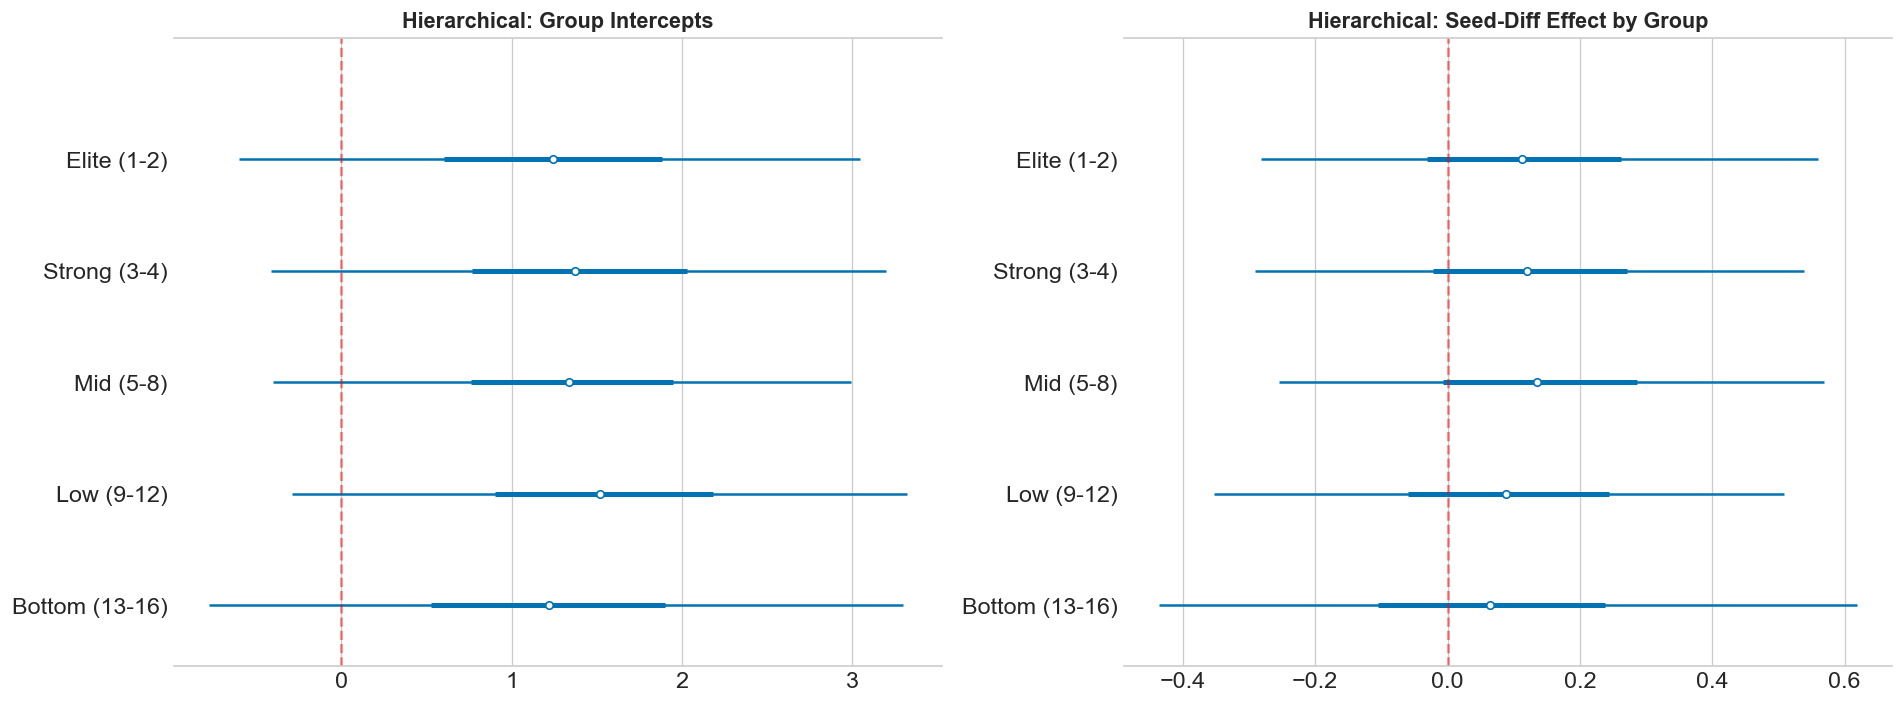


Partial pooling (hierarchical shrinkage):


,mean,sd,hdi_3%,hdi_97%,r_hat,ess_bulk
alpha_group[0],1.244,0.964,-0.602,3.046,1.0,4061.0
alpha_group[1],1.398,0.952,-0.411,3.200,1.0,4023.0
alpha_group[2],1.362,0.898,-0.400,2.995,1.0,4221.0
alpha_group[3],1.553,0.968,-0.293,3.327,1.0,4562.0
alpha_group[4],1.190,1.093,-0.780,3.302,1.0,4478.0
beta_seed_diff[0],0.116,0.223,-0.281,0.559,1.0,3970.0
beta_seed_diff[1],0.125,0.221,-0.292,0.539,1.0,3948.0
beta_seed_diff[2],0.140,0.220,-0.255,0.568,1.0,3989.0
beta_seed_diff[3],0.091,0.228,-0.353,0.508,1.0,3899.0
beta_seed_diff[4],0.047,0.291,-0.437,0.619,1.0,3578.0


In [6]:
# ============================================================
# 4.5 BAYESIAN HIERARCHICAL DIAGNOSTICS
# ============================================================
try:
    import arviz as az
    
    trace_hier = az.from_netcdf(str(MODEL_DIR / "bayesian_hier_trace.nc"))
    
    seed_group_labels = ["Elite (1-2)", "Strong (3-4)", "Mid (5-8)", "Low (9-12)", "Bottom (13-16)"]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Group-level intercepts
    ax = axes[0]
    az.plot_forest(trace_hier, var_names=["alpha_group"], combined=True, ax=ax)
    ax.set_yticklabels(seed_group_labels[::-1])
    ax.set_title("Hierarchical: Group Intercepts", fontweight="bold")
    ax.axvline(x=0, color="red", linestyle="--", alpha=0.5)
    
    # Group-level seed_diff slopes
    ax = axes[1]
    az.plot_forest(trace_hier, var_names=["beta_seed_diff"], combined=True, ax=ax)
    ax.set_yticklabels(seed_group_labels[::-1])
    ax.set_title("Hierarchical: Seed-Diff Effect by Group", fontweight="bold")
    ax.axvline(x=0, color="red", linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "bayesian_hier_posteriors.png", bbox_inches="tight")
    plt.show()
    
    # Shrinkage visualization
    print("\nPartial pooling (hierarchical shrinkage):")
    summary = az.summary(trace_hier, var_names=["alpha_group", "beta_seed_diff", "mu_alpha", "mu_beta"])
    display(summary[["mean", "sd", "hdi_3%", "hdi_97%", "r_hat", "ess_bulk"]])

except FileNotFoundError:
    log.warning("Hierarchical trace not found. Run Notebook 2 first.")
except ImportError:
    log.warning("ArviZ not installed.")
except Exception as e:
    log.error(f"Hierarchical diagnostics failed: {e}")

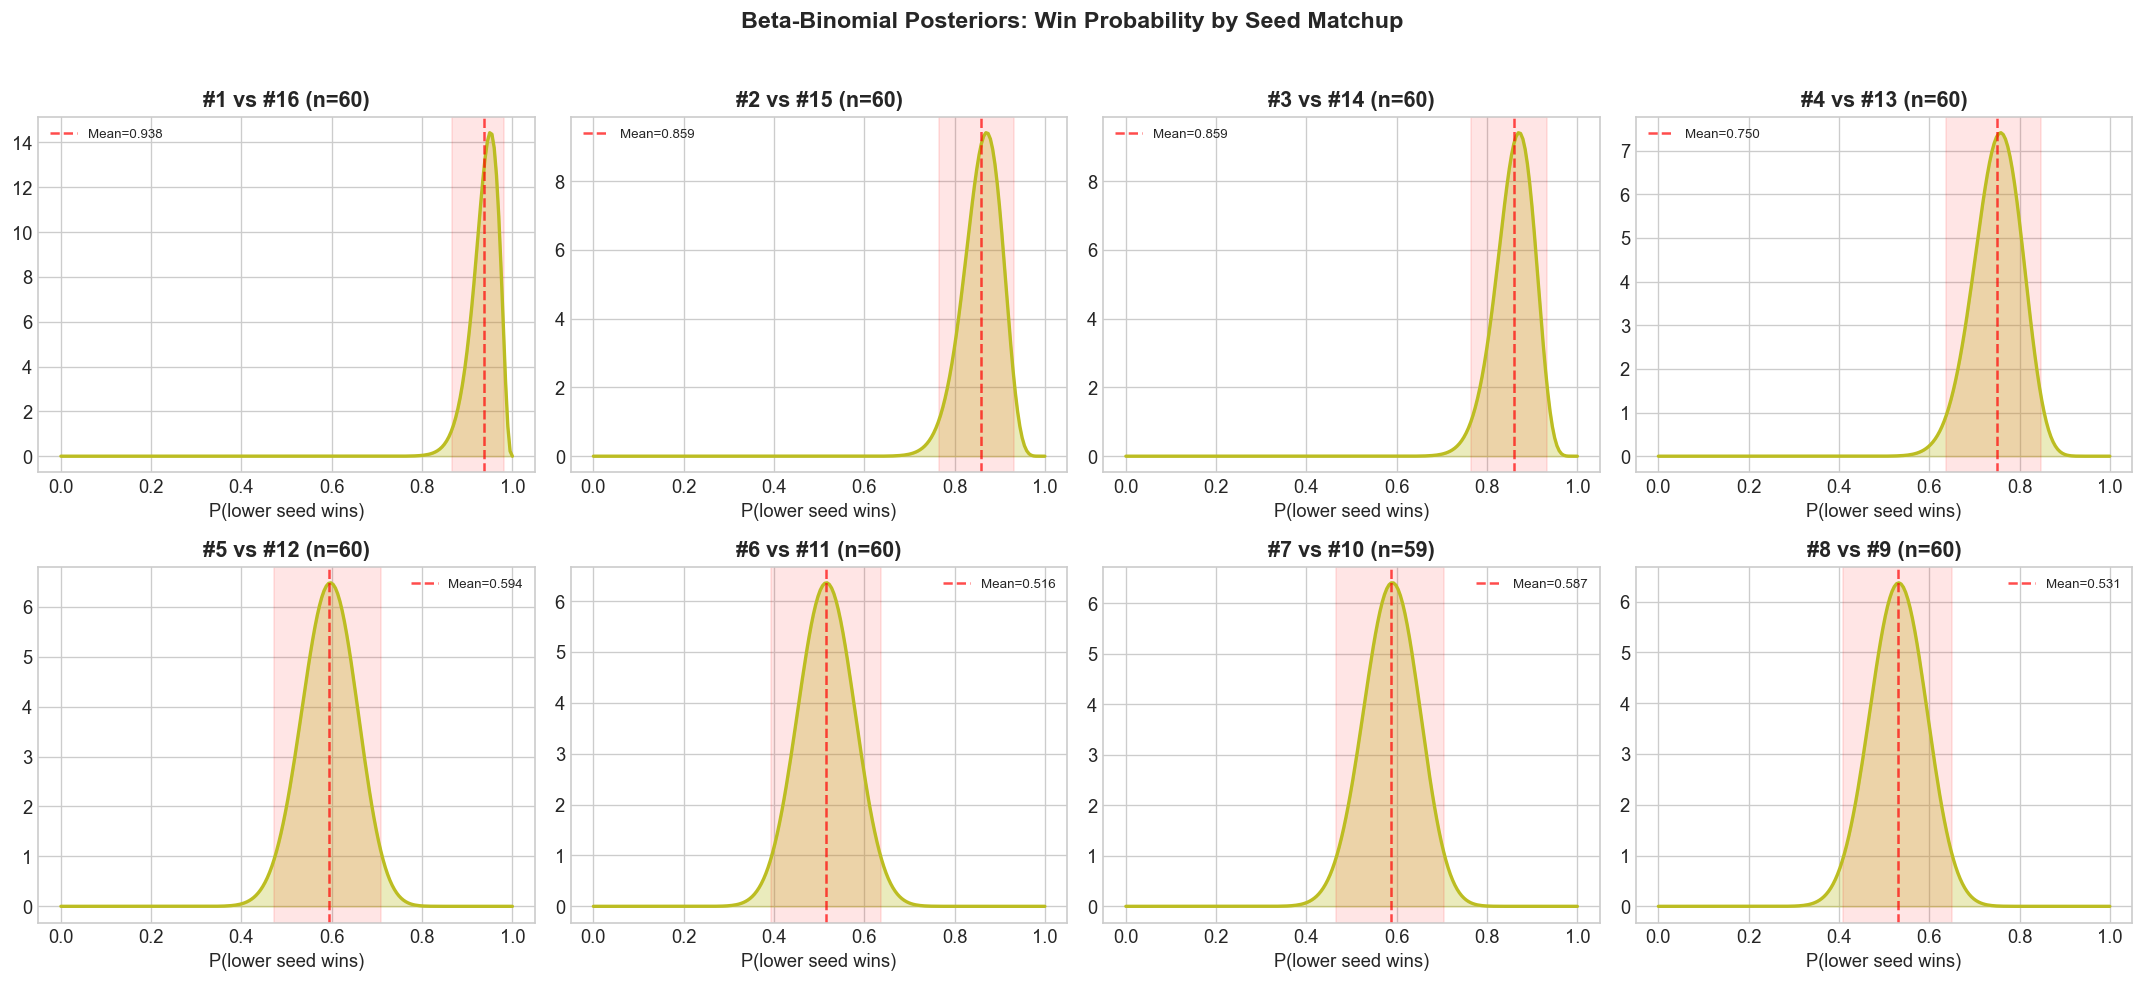

In [7]:
# ============================================================
# 4.6 BETA-BINOMIAL POSTERIOR VISUALIZATION
# ============================================================
try:
    from scipy.stats import beta as beta_dist
    
    bb_params = pickle.load(open(MODEL_DIR / "beta_binomial.pkl", "rb"))
    
    # Plot posterior Beta distributions for key matchups
    key_matchups = [(1,16), (2,15), (3,14), (4,13), (5,12), (6,11), (7,10), (8,9)]
    available = [m for m in key_matchups if m in bb_params]
    
    n_plots = len(available)
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()
    
    x = np.linspace(0, 1, 200)
    
    for i, (s1, s2) in enumerate(available):
        if i >= len(axes):
            break
        ax = axes[i]
        p = bb_params[(s1, s2)]
        
        y = beta_dist.pdf(x, p["alpha"], p["beta"])
        ax.fill_between(x, y, alpha=0.3, color=COLORS.get("BetaBinomial", "#bcbd22"))
        ax.plot(x, y, color=COLORS.get("BetaBinomial", "#bcbd22"), linewidth=2)
        
        # Mark mean and HDI
        ax.axvline(p["mean"], color="red", linestyle="--", alpha=0.7, label=f"Mean={p['mean']:.3f}")
        
        hdi_low = beta_dist.ppf(0.025, p["alpha"], p["beta"])
        hdi_high = beta_dist.ppf(0.975, p["alpha"], p["beta"])
        ax.axvspan(hdi_low, hdi_high, alpha=0.1, color="red")
        
        ax.set_title(f"#{s1} vs #{s2} (n={p['n_games']})", fontweight="bold")
        ax.set_xlabel("P(lower seed wins)")
        ax.legend(fontsize=8)
    
    # Hide unused axes
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle("Beta-Binomial Posteriors: Win Probability by Seed Matchup", 
                 fontweight="bold", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "beta_binomial_posteriors.png", bbox_inches="tight")
    plt.show()

except FileNotFoundError:
    log.warning("Beta-Binomial model not found.")
except Exception as e:
    log.error(f"Beta-Binomial visualization failed: {e}")

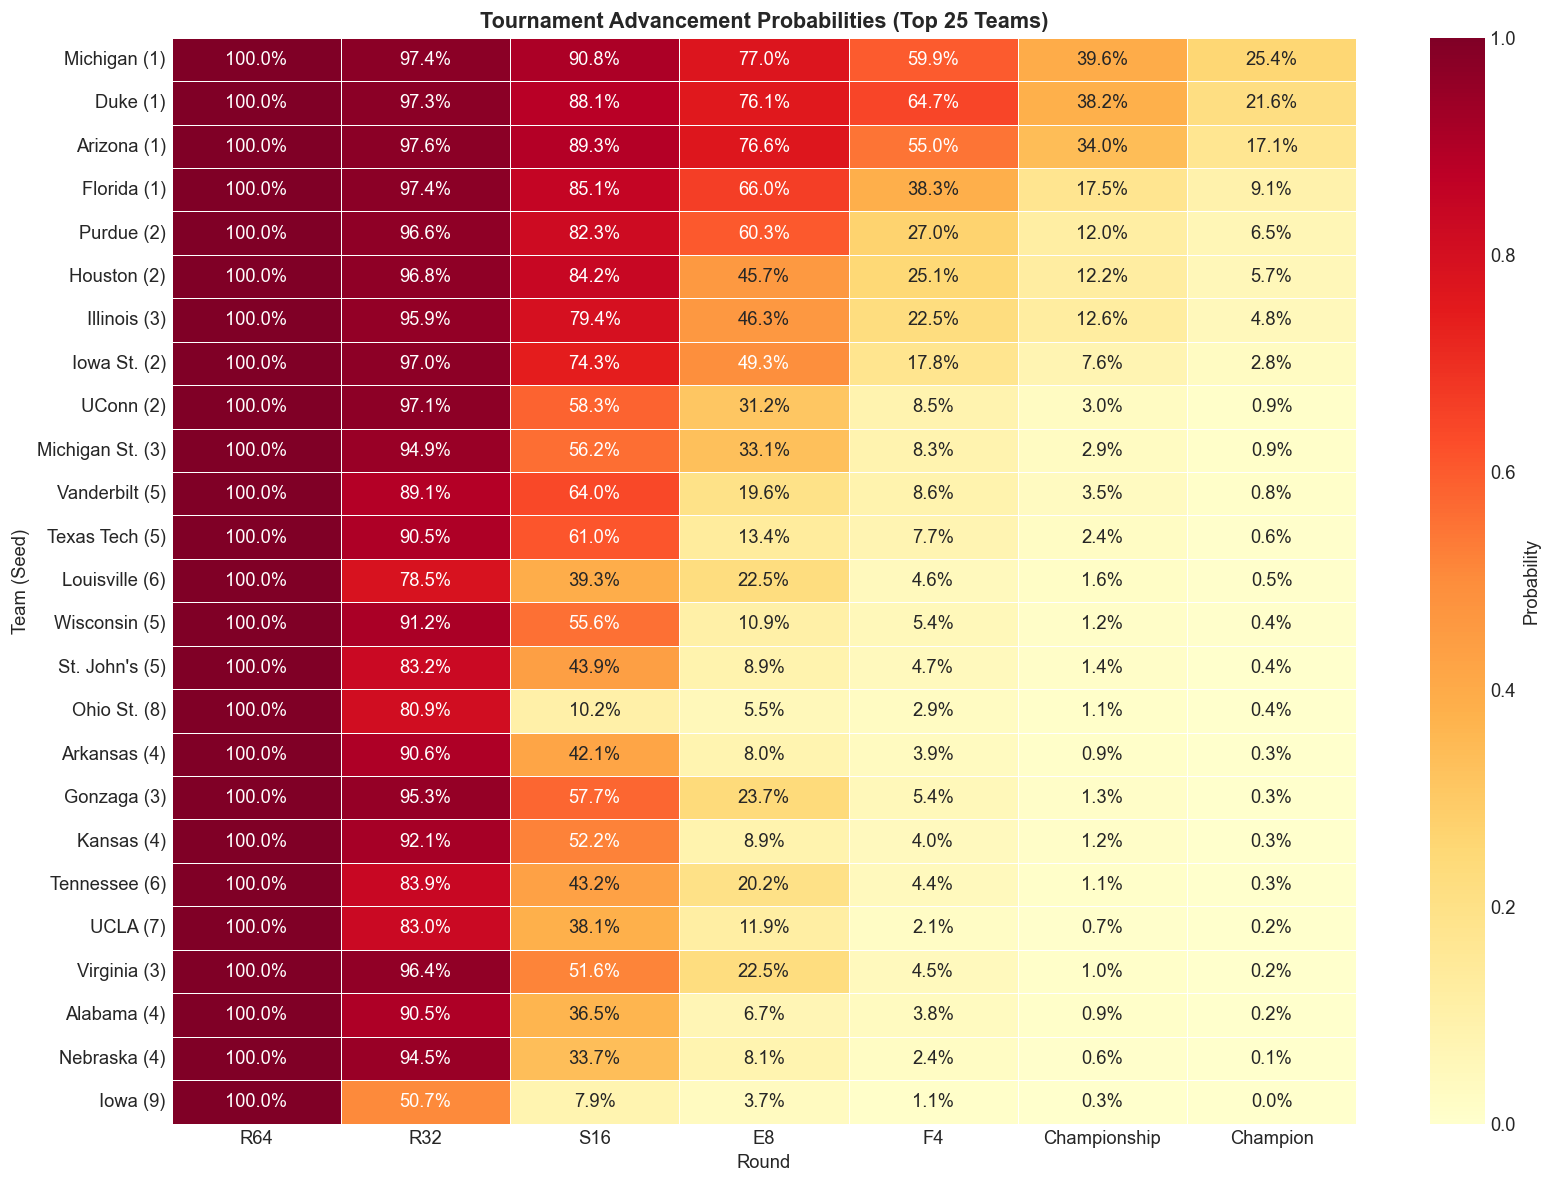

In [8]:
# ============================================================
# 4.7 ADVANCEMENT PROBABILITY HEATMAP
# ============================================================
if "prob_R64" in sim_results.columns:
    round_cols = [c for c in sim_results.columns if c.startswith("prob_")]
    
    # Top 25 teams by championship probability
    top = sim_results.sort_values("prob_Champion", ascending=False).head(25)
    
    heatmap_data = top[round_cols].copy()
    heatmap_data.index = [f"{r['team']} ({int(r['seed'])})" for _, r in top.iterrows()]
    heatmap_data.columns = [c.replace("prob_", "") for c in round_cols]
    
    fig, ax = plt.subplots(figsize=(14, 10))
    sns.heatmap(
        heatmap_data,
        annot=True, fmt=".1%",
        cmap="YlOrRd",
        linewidths=0.5,
        ax=ax,
        vmin=0, vmax=1,
        cbar_kws={"label": "Probability"},
    )
    ax.set_title("Tournament Advancement Probabilities (Top 25 Teams)", fontweight="bold")
    ax.set_xlabel("Round")
    ax.set_ylabel("Team (Seed)")
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "advancement_heatmap.png", bbox_inches="tight")
    plt.show()
else:
    log.warning("No advancement probabilities found. Run Notebook 3 first.")

2026-03-18 23:11:10,872 [INFO] Brier decomposition framework ready.
2026-03-18 23:11:10,872 [INFO] Run cross-validation in Notebook 2 to generate actual decomposition.



Brier Score Decomposition (demo):
  brier: 0.1345
  reliability: 0.0371
  resolution: 0.1398
  uncertainty: 0.2372
  calibration_error: 0.0371
  sharpness: 0.1398


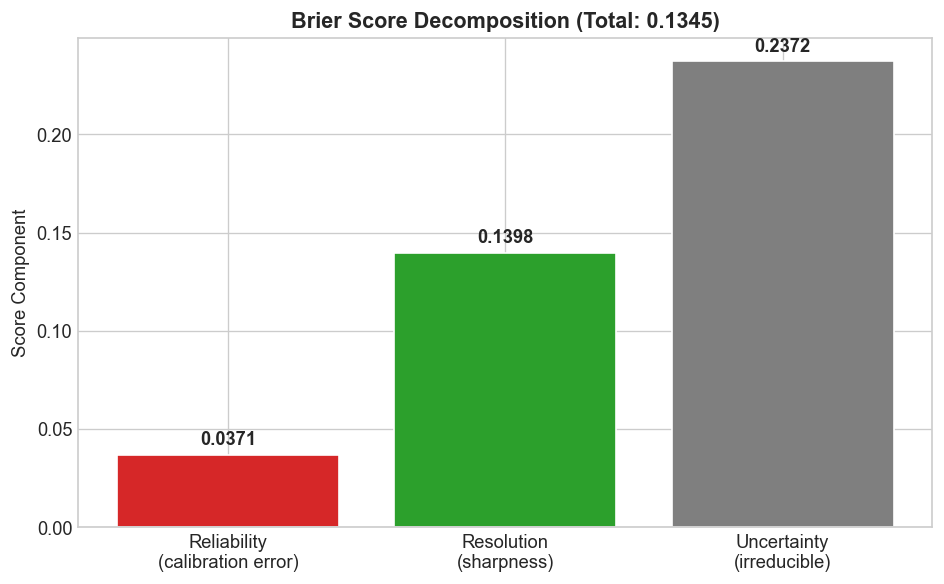

In [9]:
# ============================================================
# 4.8 BRIER SCORE DECOMPOSITION
# ============================================================
def brier_decomposition(y_true, y_prob, n_bins=10):
    """
    Decompose Brier score into reliability, resolution, and uncertainty.
    
    Brier = Reliability - Resolution + Uncertainty
    - Reliability: how close predictions are to observed frequencies (lower = better)
    - Resolution: how much predictions vary from base rate (higher = better)
    - Uncertainty: inherent unpredictability (constant for a dataset)
    """
    base_rate = y_true.mean()
    uncertainty = base_rate * (1 - base_rate)
    
    bins = np.linspace(0, 1, n_bins + 1)
    reliability = 0
    resolution = 0
    
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        n_k = mask.sum()
        if n_k == 0:
            continue
        
        f_k = y_prob[mask].mean()  # average predicted prob in bin
        o_k = y_true[mask].mean()  # observed frequency in bin
        
        reliability += n_k * (f_k - o_k) ** 2
        resolution += n_k * (o_k - base_rate) ** 2
    
    n = len(y_true)
    reliability /= n
    resolution /= n
    brier = reliability - resolution + uncertainty
    
    return {
        "brier": brier,
        "reliability": reliability,
        "resolution": resolution,
        "uncertainty": uncertainty,
        "calibration_error": reliability,
        "sharpness": resolution,
    }

# Demo with synthetic data (replace with actual CV predictions)
log.info("Brier decomposition framework ready.")
log.info("Run cross-validation in Notebook 2 to generate actual decomposition.")

# Show decomposition for synthetic example
np.random.seed(42)
n = 1000
y = np.random.binomial(1, 0.6, n)
p = np.clip(0.6 + 0.3 * (y - 0.5) + np.random.normal(0, 0.15, n), 0.01, 0.99)

decomp = brier_decomposition(y, p)
print("\nBrier Score Decomposition (demo):")
for k, v in decomp.items():
    print(f"  {k}: {v:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))
components = ["Reliability\n(calibration error)", "Resolution\n(sharpness)", "Uncertainty\n(irreducible)"]
values = [decomp["reliability"], decomp["resolution"], decomp["uncertainty"]]
colors_brier = ["#d62728", "#2ca02c", "#7f7f7f"]

bars = ax.bar(components, values, color=colors_brier, edgecolor="white", linewidth=1)
ax.set_ylabel("Score Component")
ax.set_title(f"Brier Score Decomposition (Total: {decomp['brier']:.4f})", fontweight="bold")

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "brier_decomposition.png", bbox_inches="tight")
plt.show()

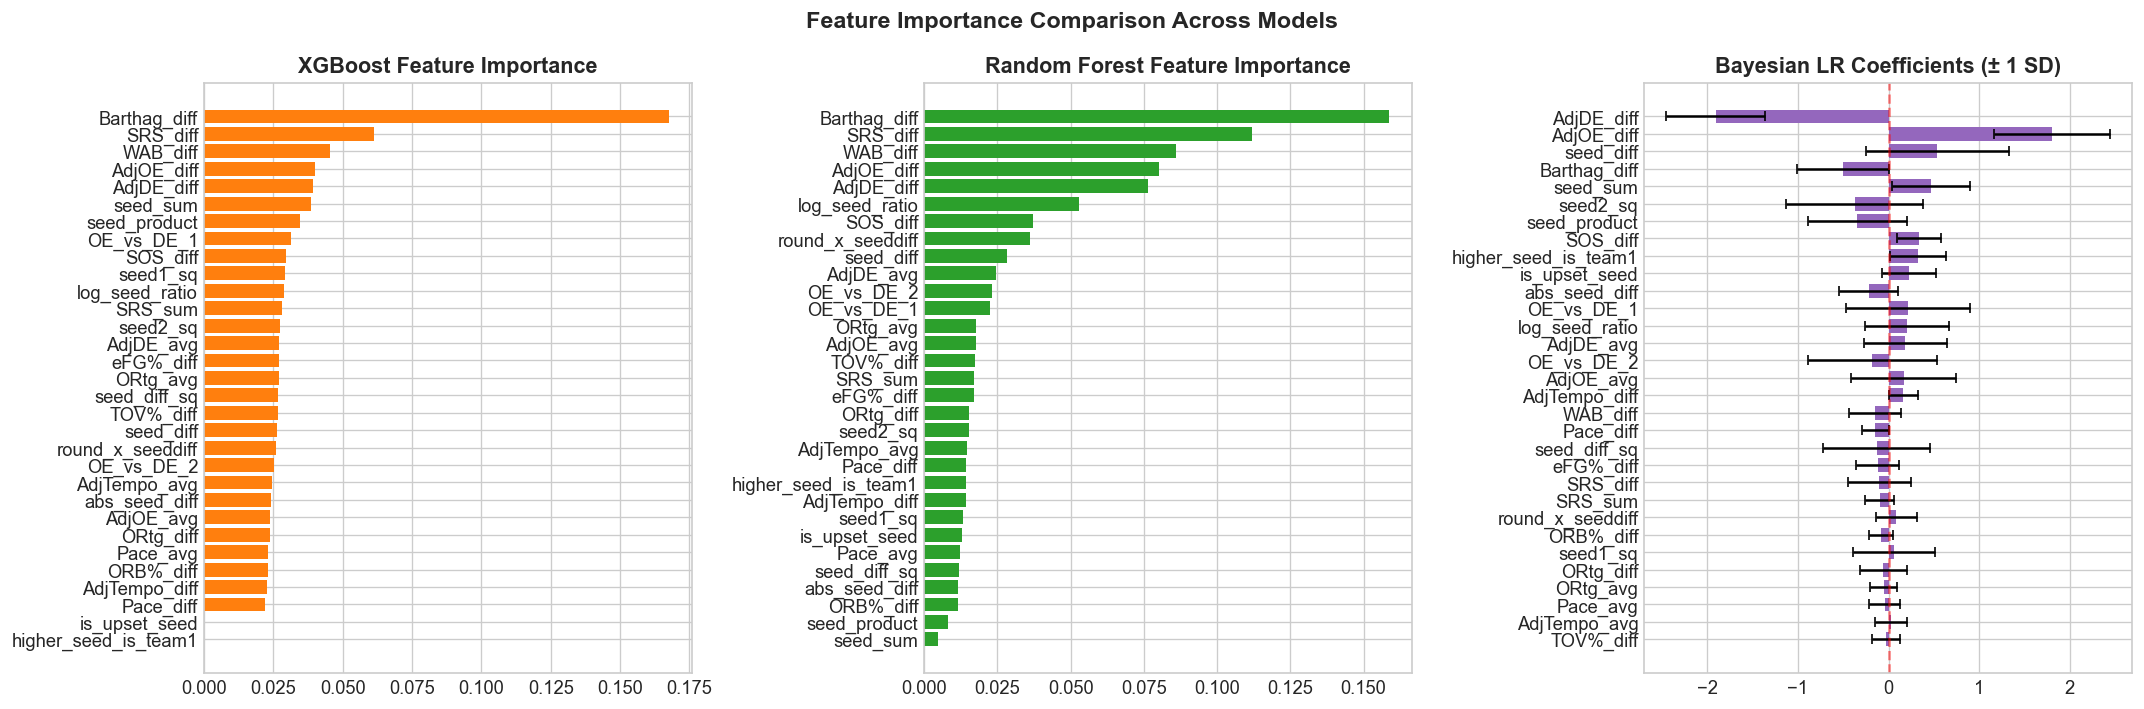

In [10]:
# ============================================================
# 4.9 FEATURE IMPORTANCE COMPARISON ACROSS MODELS
# ============================================================
import pickle

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

FEATURE_COLS = pickle.load(open(MODEL_DIR / "feature_cols.pkl", "rb"))


# --- XGBoost importance ---
try:
    xgb_model = pickle.load(open(MODEL_DIR / "xgboost.pkl", "rb"))
    ax = axes[0]
    importance = xgb_model.feature_importances_
    idx = np.argsort(importance)
    ax.barh(np.array(FEATURE_COLS)[idx], importance[idx], color=COLORS["XGBoost"])
    ax.set_title("XGBoost Feature Importance", fontweight="bold")
except Exception as e:
    log.warning(f"XGBoost importance plot failed: {e}")
    axes[0].text(0.5, 0.5, "XGBoost not available", transform=axes[0].transAxes, ha="center")

# --- Random Forest importance ---
try:
    rf_model = pickle.load(open(MODEL_DIR / "random_forest.pkl", "rb"))
    ax = axes[1]
    importance = rf_model.feature_importances_
    idx = np.argsort(importance)
    ax.barh(np.array(FEATURE_COLS)[idx], importance[idx], color=COLORS["RandomForest"])
    ax.set_title("Random Forest Feature Importance", fontweight="bold")
except Exception as e:
    log.warning(f"RF importance plot failed: {e}")
    axes[1].text(0.5, 0.5, "Random Forest not available", transform=axes[1].transAxes, ha="center")

# --- Bayesian LR coefficients ---
try:
    import arviz as az
    trace = az.from_netcdf(str(MODEL_DIR / "bayesian_lr_trace.nc"))
    ax = axes[2]
    means = trace.posterior["betas"].values.mean(axis=(0, 1))
    stds = trace.posterior["betas"].values.std(axis=(0, 1))
    idx = np.argsort(np.abs(means))
    
    ax.barh(np.array(FEATURE_COLS)[idx], means[idx], 
            xerr=stds[idx], color=COLORS["BayesLR"], capsize=3)
    ax.axvline(x=0, color="red", linestyle="--", alpha=0.5)
    ax.set_title("Bayesian LR Coefficients (± 1 SD)", fontweight="bold")
except Exception as e:
    log.warning(f"Bayesian importance plot failed: {e}")
    axes[2].text(0.5, 0.5, "Bayesian LR not available", transform=axes[2].transAxes, ha="center")

plt.suptitle("Feature Importance Comparison Across Models", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "feature_importance_comparison.png", bbox_inches="tight")
plt.show()

In [11]:
# ============================================================
# 4.10 CONTRARIAN VALUE ANALYSIS
# ============================================================
if "value_Champion" in sim_results.columns and "ownership_Champion" in sim_results.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # --- Probability vs Ownership scatter ---
    ax = axes[0]
    scatter = ax.scatter(
        sim_results["ownership_Champion"] * 100,
        sim_results["prob_Champion"] * 100,
        c=sim_results["seed"],
        cmap="RdYlGn_r",
        s=50,
        alpha=0.7,
        edgecolors="white",
        linewidth=0.5,
    )
    
    # Diagonal (fair value)
    max_val = max(sim_results["prob_Champion"].max(), sim_results["ownership_Champion"].max()) * 100
    ax.plot([0, max_val], [0, max_val], "k--", alpha=0.3, label="Fair value line")
    
    ax.set_xlabel("Estimated Public Ownership (%)")
    ax.set_ylabel("Our Model Probability (%)")
    ax.set_title("Value Map: Model Prob vs Public Ownership", fontweight="bold")
    
    # Label top value plays
    top_value = sim_results.nlargest(5, "value_Champion")
    for _, row in top_value.iterrows():
        ax.annotate(
            f"{row['team']}({int(row['seed'])})",
            (row["ownership_Champion"]*100, row["prob_Champion"]*100),
            fontsize=8, fontweight="bold",
            xytext=(5, 5), textcoords="offset points",
        )
    
    plt.colorbar(scatter, ax=ax, label="Seed")
    ax.legend()
    
    # --- Value by seed ---
    ax = axes[1]
    seed_value = sim_results.groupby("seed").agg({
        "prob_Champion": "mean",
        "value_Champion": "mean",
    }).reset_index()
    
    x = np.arange(len(seed_value))
    width = 0.35
    ax.bar(x - width/2, seed_value["prob_Champion"] * 100, width, label="Raw Probability", color="#1f77b4")
    ax.bar(x + width/2, seed_value["value_Champion"] * 100, width, label="Contrarian Value", color="#ff7f0e")
    ax.set_xticks(x)
    ax.set_xticklabels(seed_value["seed"].astype(int))
    ax.set_xlabel("Seed")
    ax.set_ylabel("Score (%)")
    ax.set_title("Raw Probability vs Contrarian Value by Seed", fontweight="bold")
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "contrarian_analysis.png", bbox_inches="tight")
    plt.show()
else:
    log.warning("Contrarian analysis requires simulation results with value columns.")

2026-03-18 23:11:11,941 [WARNING] Contrarian analysis requires simulation results with value columns.


In [13]:
# ============================================================
# 4.11 SUMMARY REPORT
# ============================================================
print("=" * 70)
print("  MARCH MADNESS 2026 PROJECTION SYSTEM - EVALUATION SUMMARY")
print("=" * 70)

print("\n MODEL PERFORMANCE:")
print(model_comparison.to_string(index=False))

print(f"\n ENSEMBLE:")
print(f"  Log-Loss: {ensemble_config.get('ensemble_logloss', 'N/A')}")
print(f"  AUC-ROC:  {ensemble_config.get('ensemble_auc', 'N/A')}")
print(f"  Weights:  {json.dumps(ensemble_config.get('weights', {}), indent=4)}")

print(f"\n TOP 5 CHAMPIONSHIP PICKS:")
top5 = sim_results.nlargest(5, "prob_Champion")
for _, row in top5.iterrows():
    print(f"  {row['team']:25s} (#{int(row['seed']):2d}) — {row['prob_Champion']:.1%}")

if "value_Champion" in sim_results.columns:
    print(f"\n TOP 5 VALUE PLAYS (contrarian-adjusted):")
    top5v = sim_results.nlargest(5, "value_Champion")
    for _, row in top5v.iterrows():
        prob = row['prob_Champion']
        own = row.get('ownership_Champion', 0)
        print(f"  {row['team']:25s} (#{int(row['seed']):2d}) — "
              f"Prob: {prob:.1%}, Ownership: {own:.1%}, Value: {row['value_Champion']:.4f}")

print(f"\n ARTIFACTS SAVED:")
for d in [PLOTS_DIR, RESULTS_DIR, MODEL_DIR]:
    files = list(d.glob("*"))
    print(f"  {d}/: {len(files)} files")
    for f in sorted(files)[:5]:
        print(f"    {f.name}")
    if len(files) > 5:
        print(f"    ... and {len(files)-5} more")

print(f"\n Evaluation complete! All plots saved to {PLOTS_DIR}/")

  MARCH MADNESS 2026 PROJECTION SYSTEM - EVALUATION SUMMARY

 MODEL PERFORMANCE:
       Model  CV_AUC  Val_AUC  Val_LL  Val_Brier  Weight
   NeuralNet  0.7903   0.8261  0.4946     0.1690  0.1981
      LogReg  0.8157   0.8163  0.4996     0.1699  0.2111
     XGBoost  0.7482   0.8239  0.5141     0.1707  0.1776
     BayesLR  0.0000   0.8120  0.5142     0.1741  0.2092
RandomForest  0.8020   0.8087  0.5154     0.1733  0.2040

 ENSEMBLE:
  Log-Loss: 0.4001
  AUC-ROC:  0.8957
  Weights:  {
    "LogReg": 0.21106037590555668,
    "XGBoost": 0.177611339176738,
    "RandomForest": 0.20403442974046718,
    "NeuralNet": 0.19814259902962553,
    "BayesLR": 0.20915125614761274
}

 TOP 5 CHAMPIONSHIP PICKS:
  Michigan                  (# 1) — 25.4%
  Duke                      (# 1) — 21.6%
  Arizona                   (# 1) — 17.1%
  Florida                   (# 1) — 9.1%
  Purdue                    (# 2) — 6.5%

 ARTIFACTS SAVED:
  plots/: 10 files
    advancement_heatmap.png
    bayesian_hier_posterio

## Evaluation Summary

### Diagnostics generated in `./plots/`:
1. **model_comparison.png** - Side-by-side metrics + ensemble weights
2. **calibration_demo.png** - Reliability diagram framework
3. **simulation_stability.png** - MC error analysis + championship distribution
4. **bayesian_lr_traces.png** - MCMC convergence (trace plots)
5. **bayesian_lr_posteriors.png** - Coefficient posterior distributions with HDI
6. **bayesian_hier_posteriors.png** - Hierarchical group-level effects
7. **beta_binomial_posteriors.png** - Beta posteriors for each seed matchup
8. **advancement_heatmap.png** - Round-by-round advancement probabilities
9. **brier_decomposition.png** - Reliability/Resolution/Uncertainty breakdown
10. **feature_importance_comparison.png** - XGBoost vs RF vs Bayesian LR
11. **contrarian_analysis.png** - Value map + seed-level contrarian analysis

### Next Steps:
- Update `data/bracket_2026.json` with actual bracket teams
- Re-run Notebooks 1-3 with real data
- After First Four: update bracket and re-simulate
- After each round: compare picks to actuals, re-optimize remaining picks